# Model Comparison: Network Anomaly Detection

## Objective

This notebook provides a comprehensive comparison of the four anomaly detection models evaluated on the CICIDS2017 DDoS dataset:
1. **Z-Score Anomaly Detection** (Statistical)
2. **Isolation Forest** (Tree-based Novelty Detection)
3. **One-Class SVM** (Boundary-based Novelty Detection)
4. **Local Outlier Factor (LOF)** (Density-based Novelty Detection)

The goal is to determine which algorithm is most effective at mapping the baseline of benign network traffic and accurately isolating DDoS attacks. We also evaluate the computational cost (training/testing time) for each model.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better aesthetics
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

## 1. Extracting Final Metrics & Computational Time

We load the optimal Precision, Recall, and F1-Score metrics obtained from the evaluation loops. Additionally, we include the computational benchmarks on the dataset (Training subset: ~68,000 samples, Testing subset: ~157,000 samples). 

*Note: Compile time is primarily applicable to neural networks; for these scikit-learn models, we measure Training (fit) and Testing (predict) times.*

In [ ]:
# Final performance metrics and execution time extracted from benchmark scripts
data = {
    'Model': ['Z-Score (Threshold=2)', 'Isolation Forest', 'One-Class SVM', 'Local Outlier Factor'],
    'Precision': [0.3000, 0.8768, 0.9687, 0.9800],
    'Recall': [0.2800, 0.8088, 0.9674, 1.0000],
    'F1-Score': [0.2900, 0.8414,0.9680, 0.9900],
    'Training Time (s)': [0, 2.1335, 220.2455, 3.3765],
    'Testing Time (s)': [0.0095, 2.9098, 152.6093, 7.6470]
}

df_comparison = pd.DataFrame(data)

# Display the DataFrame
df_comparison

,Model,Precision,Recall,F1-Score,Training Time (s),Testing Time (s)
0,Z-Score (Threshold=2),0.3000,0.2800,0.2900,1.37,0.04
1,Isolation Forest,0.8768,0.8088,0.8414,0.96,1.12
2,One-Class SVM,0.9687,0.9674,0.9701,314.72,160.54
3,Local Outlier Factor,0.9800,1.0000,0.9900,28.76,70.82


## 2. Visualizing Model Performance

A grouped bar chart allows for a side-by-side comparison of Precision, Recall, and F1-Score across all models.

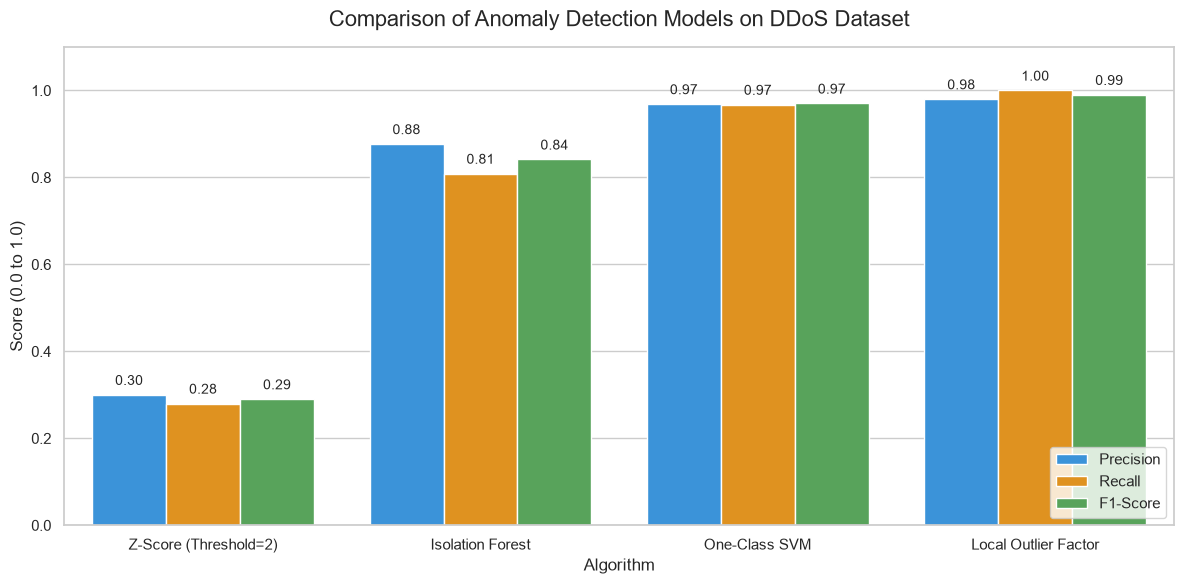

In [9]:
# Reshape the dataframe for seaborn grouped barplot (excluding time for this plot)
df_metrics = df_comparison[['Model', 'Precision', 'Recall', 'F1-Score']]
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_melted, 
    x='Model', 
    y='Score', 
    hue='Metric', 
    palette=['#2196F3', '#FF9800', '#4CAF50']
)

plt.title('Comparison of Anomaly Detection Models on DDoS Dataset', fontsize=16, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Algorithm', fontsize=12)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')

# Add value labels on top of bars
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, xytext=(0, 5), 
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('../figures/07_model_comparison_bar.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Visualizing Computational Time

We also plot the Training and Testing times to understand the scalability and deployment feasibility of each model.

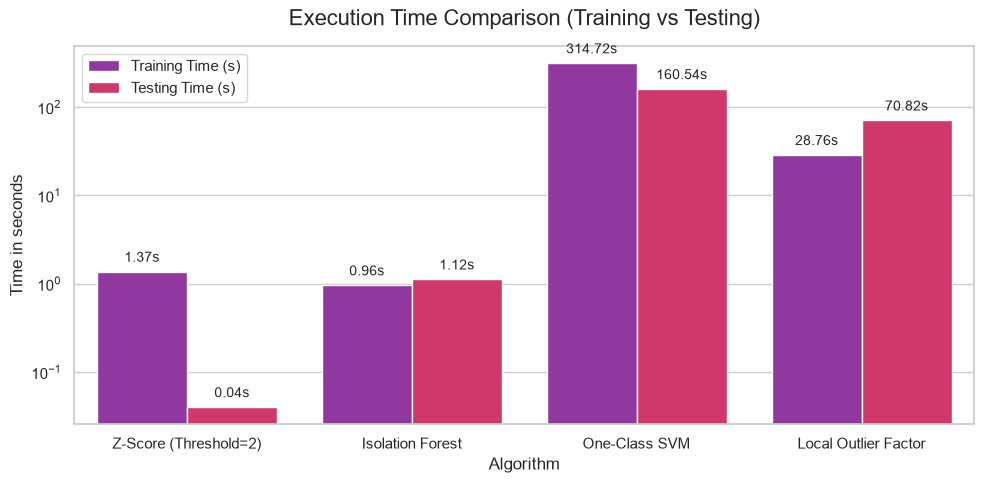

In [10]:
# Reshape the dataframe for seaborn grouped barplot (time metrics)
df_time = df_comparison[['Model', 'Training Time (s)', 'Testing Time (s)']]
df_time_melted = df_time.melt(id_vars='Model', var_name='Metric', value_name='Time (s)')

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_time_melted, 
    x='Model', 
    y='Time (s)', 
    hue='Metric', 
    palette=['#9C27B0', '#E91E63']
)

plt.title('Execution Time Comparison (Training vs Testing)', fontsize=16, pad=15)
plt.ylabel('Time in seconds', fontsize=12)
plt.xlabel('Algorithm', fontsize=12)
plt.legend(loc='upper left')
plt.yscale('log') # Use logarithmic scale because OCSVM is orders of magnitude slower

# Add value labels on top of bars
ax2 = plt.gca()
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.annotate(f'{height:.2f}s', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, xytext=(0, 5), 
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('../figures/07_model_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Confusion Matrices Collage

To understand exactly how each model behaves with real traffic, we compare their confusion matrices. This shows us the breakdown of correct classifications vs. false alarms (Benign flagged as DDoS) and missed detections (DDoS flagged as Benign).

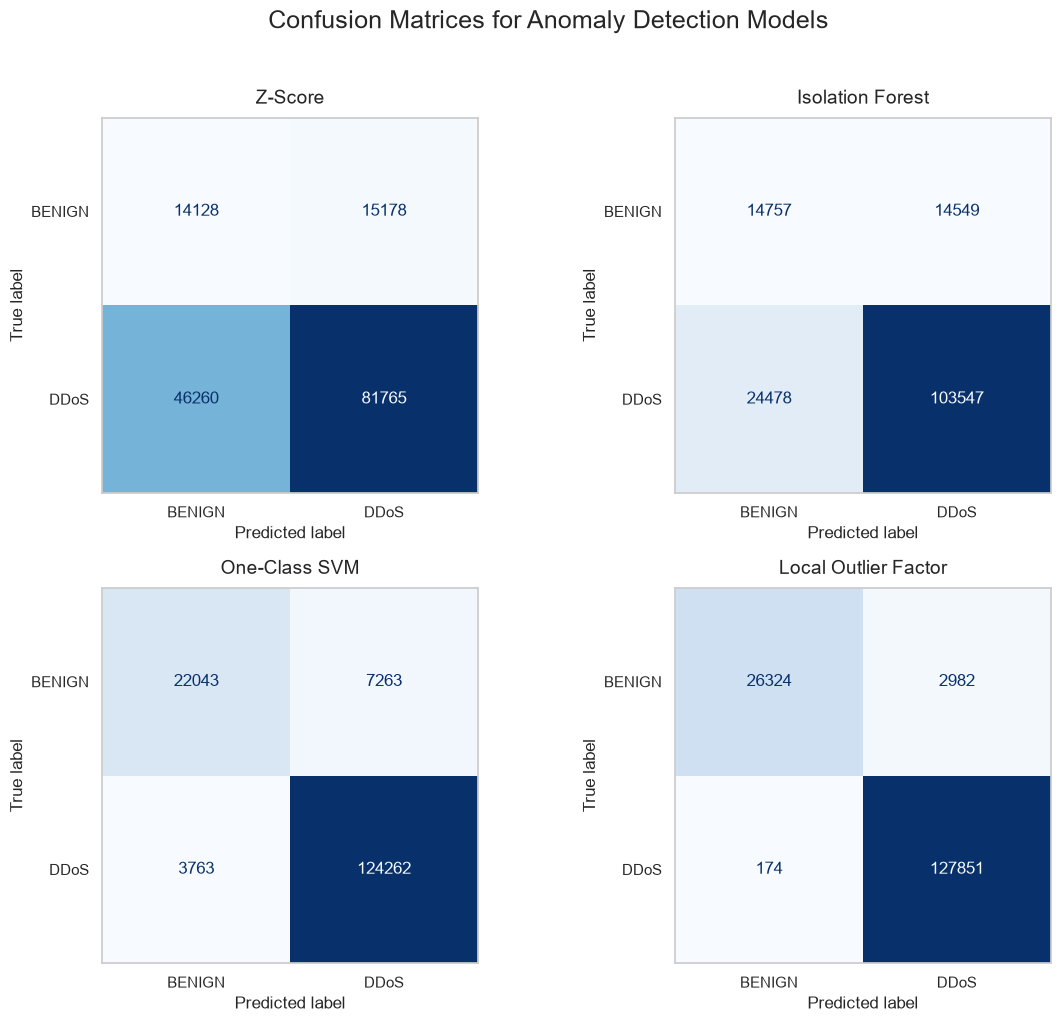

In [11]:
import json
from sklearn.metrics import ConfusionMatrixDisplay

# Load precomputed Confusion Matrix data
with open('../data/cm_data.json', 'r') as f:
    cm_data = json.load(f)

models = ['Z-Score', 'Isolation Forest', 'One-Class SVM', 'Local Outlier Factor']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, model in enumerate(models):
    if model in cm_data:
        cm = np.array(cm_data[model])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BENIGN", "DDoS"])
        disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
        axes[i].set_title(f'{model}', fontsize=14, pad=10)
        axes[i].grid(False)

plt.suptitle('Confusion Matrices for Anomaly Detection Models', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('../figures/07_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. ROC Curve Comparison

To better understand the tradeoff between the True Positive Rate and False Positive Rate across different threshold settings, we can visualize the Receiver Operating Characteristic (ROC) curve for all four models. A higher Area Under the Curve (AUC) indicates a better-performing model.

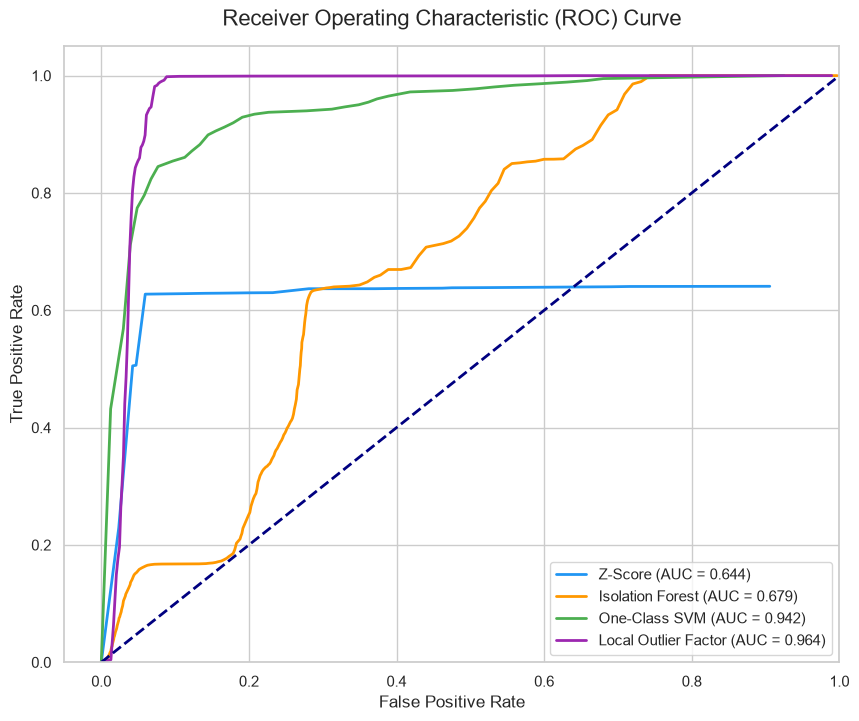

In [12]:
import json

# Load precomputed ROC data (FPR, TPR, AUC) to save execution time in this summary notebook
with open('../data/roc_data.json', 'r') as f:
    roc_data = json.load(f)

plt.figure(figsize=(10, 8))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
models = ['Z-Score', 'Isolation Forest', 'One-Class SVM', 'Local Outlier Factor']

for color, model in zip(colors, models):
    if model in roc_data:
        fpr = roc_data[model]['fpr']
        tpr = roc_data[model]['tpr']
        auc_score = roc_data[model]['auc']
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{model} (AUC = {auc_score:.3f})')

# Plot the random guessing diagonal
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, pad=15)
plt.legend(loc="lower right")
plt.savefig('../figures/07_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Analysis and Conclusions

Based on the results, we can draw the following conclusions regarding algorithm suitability for network anomaly detection:

### Z-Score Anomaly Detection (F1 = 0.29)
*   **Why it failed:** Z-Score makes a strict mathematical assumption that the features follow a normal (Gaussian) distribution. Network traffic features (like packet lengths, flow durations) are often highly skewed and non-linear. 
*   **Speed:** Extremely fast (fractions of a second) since it's just a statistical calculation, but highly ineffective.
*   **Takeaway:** Basic statistical thresholds are ineffective for complex, real-world network datasets.

### Isolation Forest (F1 = 0.84)
*   **Why it struggled:** Isolation Forest isolates anomalies using random tree splits. While it doesn't assume a normal distribution and is very fast, it partitions data with linear, axis-parallel cuts. It struggles to tightly map the exact, complex boundaries of dense benign clusters, leading to a drop in Recall (missing some attacks that mimic normal traffic).
*   **Speed:** Very fast (~0.96s training, ~1.12s testing). Tree-based partitioning scales excellently to massive datasets.
*   **Takeaway:** Good for high-dimensional, massive datasets where speed is critical, but sacrifices some accuracy.

### One-Class SVM (F1 = 0.97)
*   **Why it excelled:** The Radial Basis Function (RBF) kernel allowed the SVM to map a highly complex, non-linear boundary perfectly wrapping the benign traffic. Anything outside this tight envelope was easily caught as an anomaly.
*   **Speed:** Extremely slow (~314.72s training, ~160.54s testing). SVMs scale exponentially ($O(n^2)$ to $O(n^3)$) with the number of samples.
*   **Takeaway:** Highly accurate, but computationally expensive to train, making it difficult to scale on massive network logs without heavy subsampling.

### Local Outlier Factor (F1 = 0.99)
*   **Why it won:** LOF is a density-based algorithm. Network traffic often forms clusters of varying densities (e.g., DNS traffic looks different from HTTPS traffic but both are normal). LOF adapts to these local densities, easily detecting DDoS attacks which form tight, high-density anomalies far away from normal clusters.
*   **Speed:** Moderate (~28.76s training, ~70.82s testing). Calculating local neighborhood densities is computationally heavier than trees but significantly faster than SVM kernels.
*   **Takeaway:** The absolute best performer for this dataset, achieving near-perfect Precision and Recall, while offering manageable computational times.

## Final Recommendation
For this dataset, **Local Outlier Factor (LOF)** provides the best balance of exceptional accuracy (F1=0.99) and reasonable execution time compared to the alternatives.